# Student performance dataset

[UCI webpage](https://archive.ics.uci.edu/dataset/320/student+performance)

First, we import the libraries that we will need to load, process and visualize the data.

Details about the different libraries and provided functions can be found in their respective documentation:
- `numpy` for numerical calculations https://numpy.org/doc/stable/
- `pandas` for data manipulation and analysis https://pandas.pydata.org/docs/
- `pyplot` from `matplotlib` for basic plotting functionalities https://matplotlib.org/stable/
- `seaborn` for data visualization https://seaborn.pydata.org/

The first line below is a Python 'magic command' to display the plots in the notebook.
The last line is to somewhat increase the default figure width.

In [1]:
%matplotlib inline
import numpy
import pandas
import matplotlib.pyplot as plt
import seaborn

plt.rcParams["figure.figsize"] = (10, 5)

This dataset belongs to the area of learning analytics, containing demographic and social background as well as grades of students from two secondary schools in Portugal. It consists of two tables corresponding to two different topics, mathematics and Portuguese language.

For details about the dataset, the *UCI* webpage points to
- Cortez P., Silva A. M. G. (2008). *Using data mining to predict secondary school student performance* In: Proceedings of 5th Annual Future Business Technology Conference

The grades for the first and second period as well as a the final grade are provided. The task typically considered is to predict the final grades. Because the final grade is strongly correlated with the first and second period grades, it is easier to predict it with the intermediate grades, but it is of limited interest.

We load the two data tables from the respective files, first the Portuguese language (por) then the mathematics (mat).

In [2]:
spp_path = "./student+performance/student-por.csv"
spp_dtf = pandas.read_csv(spp_path, sep=";")
spp_dtf

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
644,MS,F,19,R,GT3,T,2,3,services,other,...,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,...,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,6,10,10,10


In [3]:
spm_path = "./student+performance/student-mat.csv"
spm_dtf = pandas.read_csv(spm_path, sep=";")
spm_dtf

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


Both tables contain the same thirty-four columns. The Portuguese language table contains 649 rows, whereas the mathematics table contains only 395 rows. In both cases each row represents a student.

According to the additional information provided at the end of the list of attributes, several students (382) appear in both tables and they can be identified by looking for matching values across the tables for a subset of identifying attributes. An example R script is provided for doing the matching, from which we can see that the attributes used for matching are
 `school`,`sex`,`age`,`address`,`famsize`,`Pstatus`,`Medu`,`Fedu`,`Mjob`,`Fjob`,`reason`,`nursery` and`internet`.

Accordingly, we will try to merge the two tables. First, we create a column in each table to store its index, allowing us to easily identify which rows in the separate tables a row in the merged table corresponds to.

In [4]:
spm_dtf["index"] = spm_dtf.index
spp_dtf["index"] = spp_dtf.index

Next, we split the attributes, between attributes used in the provided script for merging (`columns_merge`), attributes that are topic-specific (`columns_specific`), and other attributes (`columns_more`).

In [5]:
columns_merge = ["school","sex","age","address","famsize","Pstatus","Medu","Fedu","Mjob","Fjob",
                 "reason","nursery","internet"]
columns_specific = ["index", "failures", "paid", "absences", "G1", "G2", "G3"]
columns_more = [c for c in spm_dtf.columns if c not in columns_merge+columns_specific]

Then, we merge the tables on the chosen attributes. We do an *inner* merge, meaning that we will only keep records that appear in both tables, and we add suffixes to the rest of attributes, not used for matching.

In [6]:
spmerge_dtf = pandas.merge(spm_dtf, spp_dtf, on=columns_merge, how="inner", suffixes=("_mat", "_por"))
spmerge_dtf

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime_por,goout_por,Dalc_por,Walc_por,health_por,absences_por,G1_por,G2_por,G3_por,index_por
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,4,0,11,11,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,6,12,13,12,2
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,0,14,14,14,3
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,0,11,13,13,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377,MS,F,18,U,LE3,T,3,1,teacher,services,...,3,4,1,1,1,4,15,15,16,645
378,MS,F,18,U,GT3,T,1,1,other,other,...,4,4,2,2,5,3,7,8,7,590
379,MS,F,18,U,GT3,T,1,1,other,other,...,1,1,1,1,5,6,11,12,9,646
380,MS,M,17,U,LE3,T,3,1,services,services,...,4,5,3,4,2,6,10,10,10,647


The merger results in a table with 832 rows, in agreement with the statement that 382 students appear in both tables.

However, we check whether any indices from the separate tables have been duplicated in the merged table, which would indicate that the merger is not a one-to-one correspondence.

In [7]:
spmerge_dtf.loc[spmerge_dtf["index_mat"].duplicated(keep=False) | spmerge_dtf["index_por"].duplicated(keep=False),
    ["index_mat", "index_por"]]

,index_mat,index_por
78,78,78
79,78,155
108,107,107
109,107,195
117,115,115
118,115,161
146,144,78
147,144,155
151,148,115
152,148,161


We see that indeed some students from one table have been matched to two distinct students in the other table, which clearly cannot be correct.

We attempt to merge again, but this time using all attributes that are not topic-specific.

In [8]:
spmandp_dtf = pandas.merge(spm_dtf, spp_dtf, on=columns_merge+columns_more, how="inner", suffixes=("_mat", "_por"))
spmandp_dtf

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,G2_mat,G3_mat,index_mat,failures_por,paid_por,absences_por,G1_por,G2_por,G3_por,index_por
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,6,6,0,0,no,4,0,11,11,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,6,1,0,no,2,9,11,11,1
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,8,10,2,0,no,6,12,13,12,2
3,GP,F,15,U,GT3,T,4,2,health,services,...,14,15,3,0,no,0,14,14,14,3
4,GP,F,16,U,GT3,T,3,3,other,other,...,10,10,4,0,no,0,11,13,13,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
365,MS,F,19,R,GT3,T,2,3,services,other,...,5,0,387,1,no,4,10,11,10,644
366,MS,F,18,U,LE3,T,3,1,teacher,services,...,9,8,388,0,no,4,15,15,16,645
367,MS,F,18,U,GT3,T,1,1,other,other,...,5,0,389,0,no,6,11,12,9,646
368,MS,M,17,U,LE3,T,3,1,services,services,...,16,16,391,0,no,6,10,10,10,647


We obtain a table that contains twelve rows fewer, with 370 rows instead of 382.

We check whether we have any duplicate indices from the separate tables.

In [9]:
spmandp_dtf.loc[spmandp_dtf["index_mat"].duplicated(keep=False) | spmandp_dtf["index_por"].duplicated(keep=False),
    ["index_mat", "index_por"]]

,index_mat,index_por


Indeed, there are none, so the merger on the larger set of columns is a one-to-one correspondence.

Further, we check some properties of the matched indices from the separate tables, under the two merging strategies.

In [10]:
for (topic, suff) in [("mathematics", "_mat"), ("Portuguese language", "_por")]:
    diffA = set(spmerge_dtf["index"+suff].values).difference(spmandp_dtf["index"+suff].values)
    diffB = set(spmandp_dtf["index"+suff].values).difference(spmerge_dtf["index"+suff].values)
    if len(diffA) + len(diffB) == 0:
        print(f"The indices from the {topic} table appearing in the merged table are the same for both merging strategies.")
    else:
        for (whichX, diffX) in [("on the columns from the provided script", diffA),
                           ("on the larger set of columns", diffB)]:
            if len(diffX) > 0:
                s  = f"Some indices from the {topic} table"
                s += f" appear in the merged table only when merged {whichX}"
                s += " (namely %s)." % ", ".join(["%d" % v for v in diffX])
                print(s)

print(("When merged on the columns from the provided script,\n" + \
      " there are %d and %d unique indices from the Portuguese language and mathematics tables, respectively,\n" +\
      " with %d and %d non-monotonic successive values.") % (
      len(set(spmerge_dtf["index_por"].values)), len(set(spmerge_dtf["index_mat"].values)),
      (numpy.diff(spmerge_dtf["index_por"].values) <= 0).sum(), (numpy.diff(spmerge_dtf["index_mat"].values) <= 0).sum()
      ))

print(("When merged on the larger set of columns,\n" + \
      " there are %d and %d unique indices from the Portuguese language and mathematics tables, respectively,\n" +\
      " with %d and %d non-monotonic successive values.") % (
      len(set(spmandp_dtf["index_por"].values)), len(set(spmandp_dtf["index_mat"].values)),
      (numpy.diff(spmandp_dtf["index_por"].values) <= 0).sum(), (numpy.diff(spmandp_dtf["index_mat"].values) <= 0).sum()
      ))

The indices from the mathematics table appearing in the merged table are the same for both merging strategies.
Some indices from the Portuguese language table appear in the merged table only when merged on the columns from the provided script (namely 590, 271, 151, 376).
When merged on the columns from the provided script,
 there are 374 and 370 unique indices from the Portuguese language and mathematics tables, respectively,
 with 12 and 12 non-monotonic successive values.
When merged on the larger set of columns,
 there are 370 and 370 unique indices from the Portuguese language and mathematics tables, respectively,
 with 0 and 0 non-monotonic successive values.


Observing
- that the same 370 indices from the smaller table (mathematics), are matched with the two strategies,
- that four extra indices from the larger table (Portuguese language) are matched when using only the columns specified in the provided script, and
- that the order of indices matched when using the larger set of columns is monotone

increases our confidence that this merging strategy is correct.

Finally, we show how the previously duplicated indices are matched in the one-to-one correspondence.

In [11]:
spmandp_dtf.loc[spmandp_dtf["index_mat"].isin(spmerge_dtf.loc[spmerge_dtf["index_mat"].duplicated(), "index_mat"].values),
    ["index_mat", "index_por"]]

,index_mat,index_por
78,78,78
107,107,107
115,115,115
143,144,155
147,148,161
176,181,195
238,243,270
272,277,319
278,283,328
312,328,380


We see that indeed the indices in each of the three lists grow monotonically. Indices from the mathematics table are equal or larger than the indices in the merged table by small values, whereas indices from the Portuguese language table are larger still. This means that only a few students from the mathematics table are skipped during matching, as they do not appear in the other table, whereas many more students from the Portuguese language table are skipped, as expected given that the latter table is much larger than the former.

In [12]:
spmandp_dtf["G3_avg"] = spmandp_dtf[["G3_mat", "G3_por"]].mean(axis=1)
spmandp_dtf["failures"] = "neither"
spmandp_dtf.loc[spmandp_dtf["failures_por"] > 0, "failures"] = "por"
spmandp_dtf.loc[spmandp_dtf["failures_mat"] > 0, "failures"] = "mat"
spmandp_dtf.loc[(spmandp_dtf["failures_por"] > 0) & (spmandp_dtf["failures_mat"] > 0), "failures"] = "both"
spmandp_dtf["absences"] = spmandp_dtf["absences_mat"]+spmandp_dtf["absences_por"]

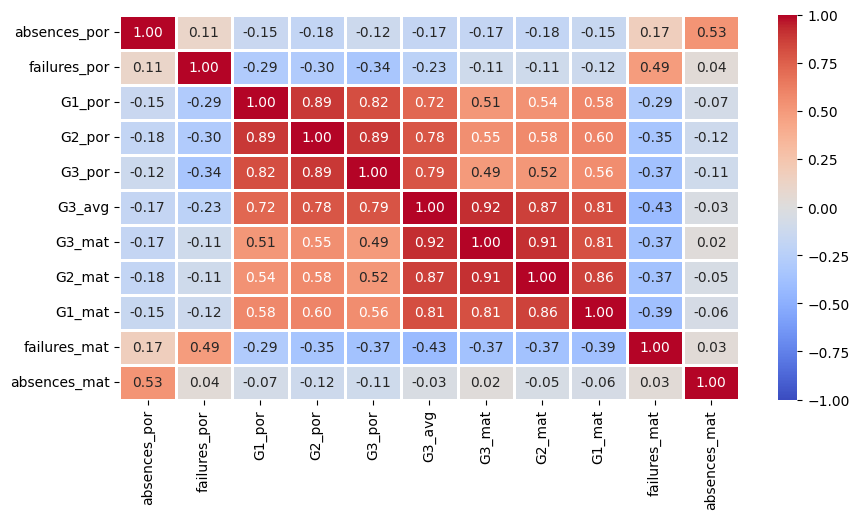

In [13]:
columns_corr = ["absences_por", "failures_por",
                "G1_por", "G2_por", "G3_por",
                "G3_avg",
                "G3_mat", "G2_mat", "G1_mat",
                "failures_mat", "absences_mat"]
crm = spmandp_dtf[columns_corr].corr()
seaborn.heatmap(crm, linewidth=.8, vmin=-1, vmax=1, annot=True, fmt=".2f", cmap="coolwarm");

The grades are all strongly positively correlated within a topic (correlations above 0.80) and less strongly across the topics (correlations in the range 0.49&mdash;0.60).
Failures are somewhat negatively correlated with grades in the corresponding topic (correlations -0.29, -0.30 and -0.34 for Portuguese language and -0.37, -0.37 and -0.39 for mathematics), indicating that, expectedly, lower grades in a topic are associated with more failures in it. Somewhat surprisingly failures in mathematics are slightly more strongly negatively correlated with grades in Portuguese language (correlations -0.29, -0.35 and -0.37).
Absences are hardly correlated with grades but quite strongly positively correlated across topics (0.53 correlation).

We draw scatter plots of students grades, in two columns, the left-hand side for the Portuguese language course and the right-hand side for the mathematics courses.

On the first row, we plot the grades for the first period (horizontal axis) against the grades for the second period (vertical axis) with the size and color of the circles depicting the final grade.
On the second and third rows, we plot the final grades (horizontal axis) against the grades for the first period and the second period (vertical axis), respectively, with the size and color of the circles depicting the final grade for the other topic.

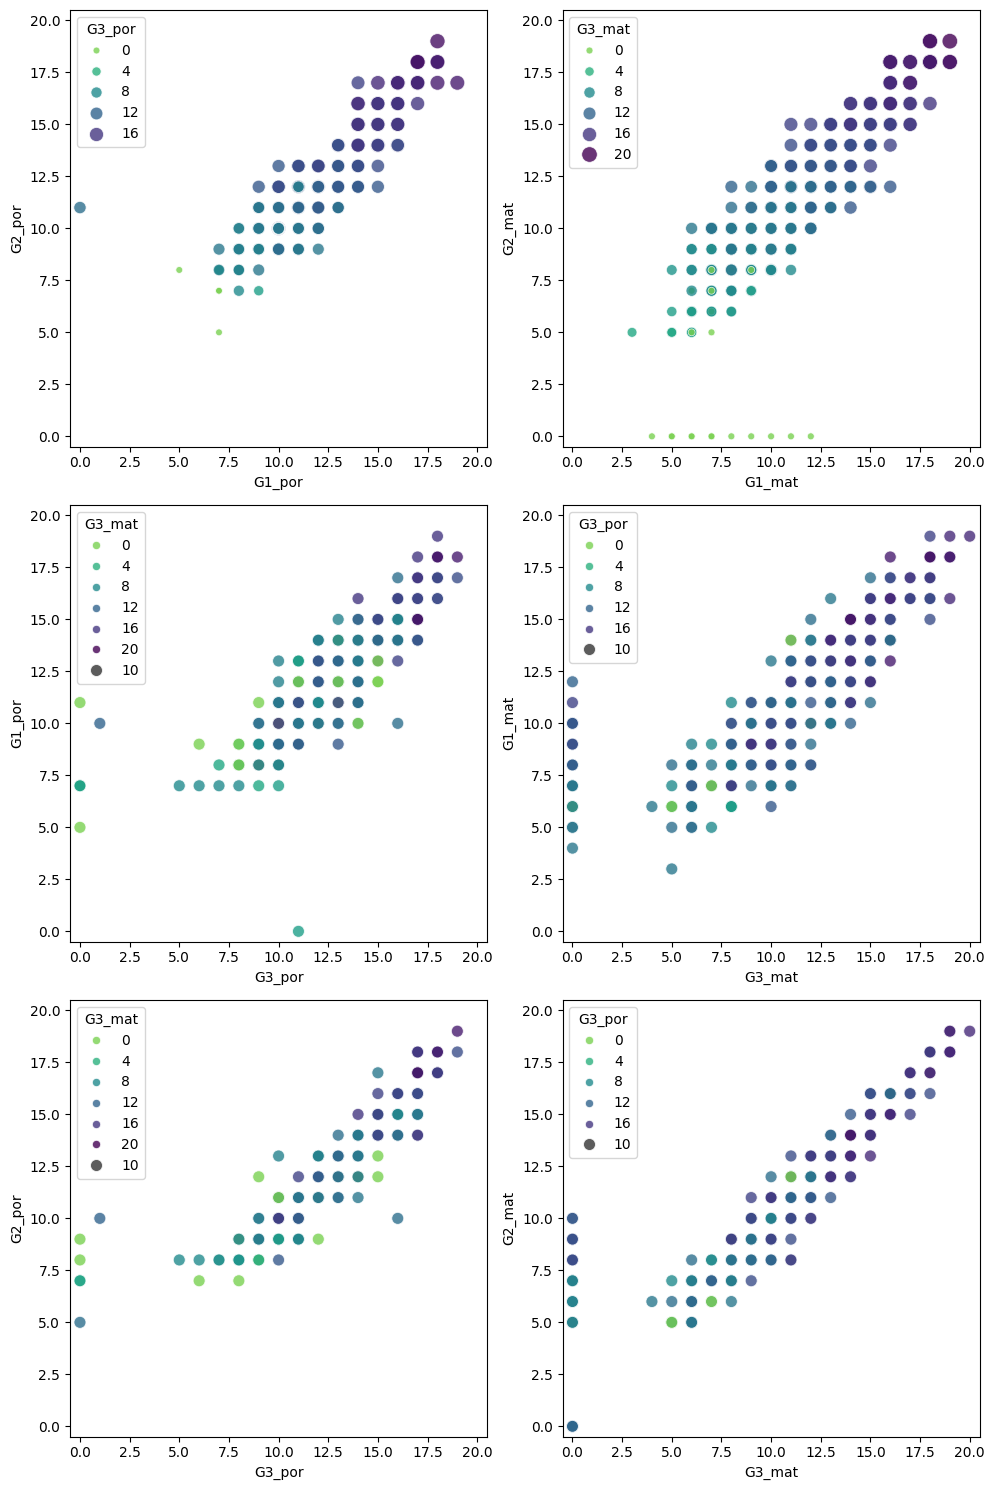

In [14]:
f, axes = plt.subplots(3, 2)
suffixes = ["_por", "_mat"]
palette_grade = "viridis_r"
for i, suff in enumerate(suffixes):

    seaborn.scatterplot(x=spmandp_dtf[f"G1{suff}"], y=spmandp_dtf[f"G2{suff}"],
                        size=spmandp_dtf[f"G3{suff}"], size_norm=(0, 20), sizes=(25, 125),
                        hue=spmandp_dtf[f"G3{suff}"], hue_norm=(-5,20), palette=palette_grade, alpha=0.8,
                        ax=axes[0,i])
    axes[0,i].set_xlim([-.5,20.5])
    axes[0,i].set_ylim([-.5,20.5])

    seaborn.scatterplot(x=spmandp_dtf[f"G3{suff}"], y=spmandp_dtf[f"G1{suff}"],
                        size=10, size_norm=(0, 20), sizes=(25, 125),
                        hue=spmandp_dtf[f"G3{suffixes[1-i]}"], hue_norm=(-5,20), palette=palette_grade, alpha=0.8,
                        ax=axes[1,i])
    axes[1,i].set_xlim([-.5,20.5])
    axes[1,i].set_ylim([-.5,20.5])

    seaborn.scatterplot(x=spmandp_dtf[f"G3{suff}"], y=spmandp_dtf[f"G2{suff}"],
                        size=10, size_norm=(0, 20), sizes=(25, 125),
                        hue=spmandp_dtf[f"G3{suffixes[1-i]}"], hue_norm=(-5,20), palette=palette_grade, alpha=0.8,
                        ax=axes[2,i])
    axes[2,i].set_xlim([-.5,20.5])
    axes[2,i].set_ylim([-.5,20.5])

f.set_figheight(15)
f.tight_layout()

As expected from the correlation matrix, grades are strongly linearly correlated, with circles concentrated along the diagonal in all plots, and especially the third row, showing second period grades against final grades. The weaker correlations of grades across topic shows is evident from colors being more regularly distributed across the value space in plots of the top row than of the middle and bottom rows.

The correlation of finals grades with first and second period grades are 0.82 and 0.89, respectively, in Portuguese language and 0.81 and 0.91, respectively, in mathematics. In mathematics, we notice that some students with the same grades in the first and second period did not obtain the same final grade, as visible from darker smaller dots sharing the same position with larger lighter dots in the right-hand side plot in the top row.

We investigate this further by computing an inner merge between the rows of the table corresponding to students who received zero as final grade in mathematics, on one hand, and students who received a positive final grade in mathematics, on the other hand, matching on the first and second period grades in mathematics.

In [15]:
spmandpZvNZ_dtf = pandas.merge(spmandp_dtf.loc[spmandp_dtf["G3_mat"] == 0],
                               spmandp_dtf.loc[spmandp_dtf["G3_mat"] > 0],
                               on=["G1_mat","G2_mat"], how="inner", suffixes=("_Z", "_NZ"))
spmandpZvNZ_dtf[["G1_mat","G2_mat","index_mat_Z","G3_mat_Z","index_mat_NZ","G3_mat_NZ"]]

,G1_mat,G2_mat,index_mat_Z,G3_mat_Z,index_mat_NZ,G3_mat_NZ
0,7,9,140,0,85,8
1,7,9,140,0,99,8
2,7,9,140,0,255,8
3,7,9,140,0,388,8
4,6,7,146,0,213,8
...,...,...,...,...,...,...
137,6,5,389,0,18,5
138,6,5,389,0,177,6
139,6,5,389,0,373,5
140,6,5,389,0,384,5


We identify 142 pairs of students who obtained identical intermediate grades but one student obtained a zero while the other obtained a positive grade.

For example, we find that students at indices 140, 85, 99, 255 and 388 in the mathematics table all obtained a grade of 7 in the first period and a grade of 9 in the second period, but the first student received a final grade of zero while the other four students received a final grade of 8.

Similarly we compute an inner merge of the table with itself, matching on the first and second period grades in mathematics, then we filter pairs where the first student obtained a final grade in mathematics strictly lower than that of the other student.

In [16]:
spmandpM12mat_dtf = pandas.merge(spmandp_dtf, spmandp_dtf,
                               on=["G1_mat","G2_mat"], how="inner", suffixes=("_L", "_H"))
spmandpM12mat_dtf.loc[spmandpM12mat_dtf["G3_mat_L"] < spmandpM12mat_dtf["G3_mat_H"],
    ["G1_mat","G2_mat","index_mat_L","G3_mat_L","index_mat_H","G3_mat_H"]]

,G1_mat,G2_mat,index_mat_L,G3_mat_L,index_mat_H,G3_mat_H
16,15,15,5,15,22,16
19,15,15,5,15,115,16
26,12,12,6,11,41,12
27,12,12,6,11,73,14
29,12,12,6,11,211,13
...,...,...,...,...,...,...
2568,11,12,393,10,46,11
2569,11,12,393,10,74,11
2570,11,12,393,10,186,11
2571,11,12,393,10,190,13


We find 726 such pairs. For example, we find that students at indices 5 and 22 in the mathematics table both obtained a grade of 15 in both the first and second periods, but the former received a final grade of 15 while the latter received a final grade of 16.
Student at index 115 in the mathematics table also obtained a grade of 15 in both the first and second periods and a final grade of 16.

We do the same with the grades for the Portuguese language...

In [17]:
spmandpM12por_dtf = pandas.merge(spmandp_dtf, spmandp_dtf,
                               on=["G1_por","G2_por"], how="inner", suffixes=("_L", "_H"))
spmandpM12por_dtf.loc[spmandpM12por_dtf["G3_por_L"] < spmandpM12por_dtf["G3_por_H"],
    ["G1_por","G2_por","index_por_L","G3_por_L","index_por_H","G3_por_H"]]

,G1_por,G2_por,index_por_L,G3_por_L,index_por_H,G3_por_H
8,12,13,2,12,20,14
9,12,13,2,12,22,14
12,12,13,2,12,98,13
13,12,13,2,12,99,13
15,12,13,2,12,123,13
...,...,...,...,...,...,...
4496,10,11,648,11,302,12
4497,10,11,648,11,308,12
4498,10,11,648,11,388,12
4500,10,11,648,11,628,12


... and find 1239 pairs of students who obtained the same intermediate grades but the first got a strictly lower final grade.

In [18]:
spmandpM12por_dtf.loc[(spmandpM12por_dtf["G3_por_L"] < spmandpM12por_dtf["G3_por_H"]) & (spmandpM12por_dtf["G3_por_L"] == 0),
    ["G1_por","G2_por","index_por_L","G3_por_L","index_por_H","G3_por_H"]]

,G1_por,G2_por,index_por_L,G3_por_L,index_por_H,G3_por_H
1910,11,9,163,0,71,10
1912,11,9,163,0,166,11
1913,11,9,163,0,186,10
1914,11,9,163,0,191,10
1915,11,9,163,0,230,10


Among them is a single case of a student getting a final grade of zero.
Indeed, students at indices 163, 71, 186, 191, 230 and 166 in the Portuguese language table all obtained a grade of 11 in the first period and a grade of 9 in the second period, but the first student received a final grade of zero while the next four received a final grade of 10 and the last a final grade of 11.

These observed differences in grades might be explained by the use of different coefficients applied to assignments to calculate intermediate grade versus final grades, which might also explain why final grades are strongly but not perfectly correlated with intermediate grades.

Next, we look at the distribution of values for each attributes.

We write a function to generate descriptive statistics about a dataset, somewhat similarly to *pandas'* `describe` function but focusing on the most frequent values in each column.

In [19]:
def frequent_describe(dtf, absolute=True, represent_fraction=.95, max_vals_few=8, min_vals_many=15):
    """Generate descriptive statistics about a dataset, focusing on the most frequent values in each column.

        Parameters
        ----------
        dtf: pandas.DataFrame
            The considered dataset
        absolute: bool
            Whether to report occurrence statistics as absolute counts (default) or as relative frequencies
        represent_fraction: float
            The fraction of occurrences for determining representative values. Specifically, the most common values
            whose frequencies sum to at least this threshold are considered representative values
        max_vals_few: int
            The maximum number of distinct values for a column to be considered as taking few distinct values
        min_vals_many: int
            The minimum number of distinct values for a column to be considered as taking many distinct values

        Returns
        ----------
        A data frame with one row for each column of the considered dataset, containing as columns
            name: the name of the column
            unique: the number of unique values
            freq: occurrence statistics of the most frequent value
            freq_second: occurrence statistics of the second most frequent value
            nb_represent: number of distinct representative values
            values:
                for a column taking few distinct values, all these values and associated occurrence statistics are reported
                for a column taking an intermediate number of distinct values, the first two and last two values are reported,
                    with the associated occurrence statistics
                for a column taking many distinct values, only the first and last values are reported, without occurrence statistics
    """
    col_stats = []
    tot = len(dtf)
    fmt = "%s:%d" if absolute else "%s:%.3f"
    for ci, c in enumerate(dtf.columns):
        cv = dtf.value_counts(c).sort_values(ascending=False)
        nb = (cv.cumsum()/tot < represent_fraction).sum()+1
        if not absolute:
            cv /= cv.sum()
        if len(cv) < max_vals_few:
            vals = " ".join([fmt % kv for kv in cv.sort_index().items()])
        elif len(cv) < min_vals_many:
            xvals = list(cv.items())
            vals = " ".join([fmt % kv for kv in xvals[:2]] + ["..."] + \
                            [fmt % kv for kv in xvals[-2:]])
        else:
            xvals = list(cv.sort_index().items())
            vals = " ".join([fmt % xvals[0], "...", fmt % xvals[-1]])
        col_stats.append((c, len(cv), cv.values[0], cv.values[1], nb, vals))
    return pandas.DataFrame(col_stats, columns=["name", "unique", "freq", "freq_second", "nb_represent", "values"])

We apply it to our dataset, showing the relative frequency of the two most frequent values, and counting how many of the most frequent values together constitute 80% of occurrences.

In [20]:
cols = frequent_describe(spmandp_dtf, absolute=False, represent_fraction=.8)
cols

,name,unique,freq,freq_second,nb_represent,values
0,school,2,0.894595,0.105405,1,GP:0.895 MS:0.105
1,sex,2,0.527027,0.472973,2,F:0.527 M:0.473
2,age,7,0.275676,0.262162,4,15:0.219 16:0.276 17:0.262 18:0.208 19:0.030 2...
3,address,2,0.781081,0.218919,2,R:0.219 U:0.781
4,famsize,2,0.718919,0.281081,2,GT3:0.719 LE3:0.281
5,Pstatus,2,0.897297,0.102703,1,A:0.103 T:0.897
6,Medu,5,0.348649,0.259459,3,0:0.008 1:0.132 2:0.259 3:0.251 4:0.349
7,Fedu,5,0.283784,0.262162,4,0:0.005 1:0.197 2:0.284 3:0.262 4:0.251
8,Mjob,5,0.362162,0.251351,4,at_home:0.143 health:0.089 other:0.362 service...
9,Fjob,5,0.554054,0.278378,2,at_home:0.043 health:0.046 other:0.554 service...


For example, attribute `school` takes two distinct values, namely **GP** and **MS**, standing for the two different high schools included in the dataset, namely *Gabriel Pereira* and *Mousinho da Silveira*. About 89% of students in the dataset visit the former while the remaining 11% visit the latter.

Attribute `famrel` takes five distinct values recording the quality of family relationships, from very bad (1) to excellent (5). The most frequent value is **4**, reported for about 49% of the students, followed by value **5**, reported for about 27% of the students, then by value **3**. Together with value **3**, these values represent more than 80% of the occurrences.

In [21]:
print(f"In {(cols["freq"] <= 0.8).sum()} columns, the single most frequent values appears in more than 80% of the rows.")

In 34 columns, the single most frequent values appears in more than 80% of the rows.


Next we show histograms of the final grade distributions in mathematics (left-hand side column), in Portuguese language (middle column), and the average over the two topics (right-hand side column), broken down into groups corresponding to different numbers of failures in the topic (top row) and to different number of absences (bottom row).

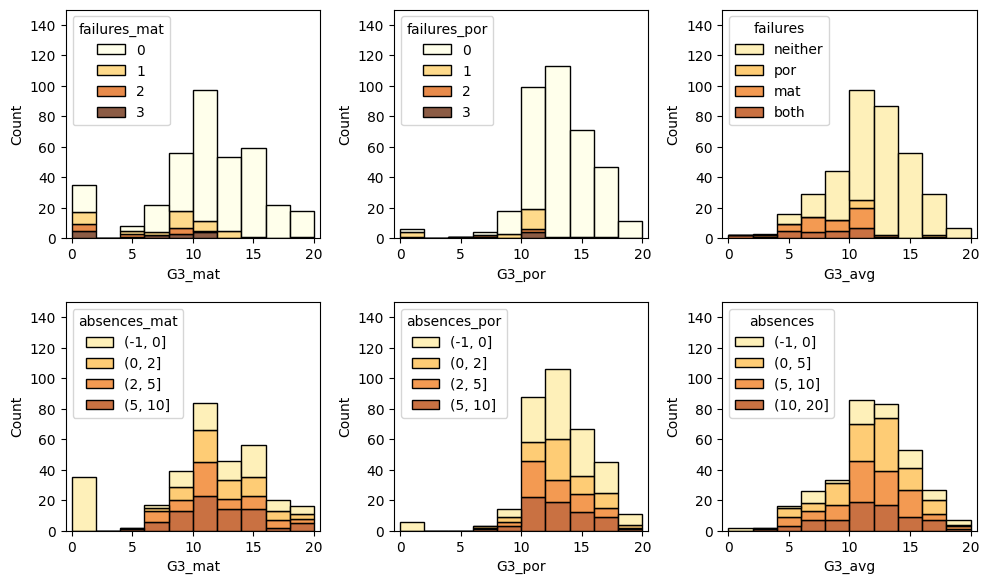

In [22]:
f, axes = plt.subplots(2, 3)
for si, suff in enumerate(["_mat", "_por"]):
    seaborn.histplot(x=spmandp_dtf["G3"+suff], hue=spmandp_dtf["failures"+suff], palette="YlOrBr",
                     binwidth=2, binrange=(0,20), multiple="stack", ax=axes[0,si])
    axes[0,si].set_xlim([-0.5,20.5])
    axes[0,si].set_ylim([0,150])
    absence_cats = pandas.cut(spmandp_dtf["absences"+suff], [-1,0,2,5,10])
    seaborn.histplot(x=spmandp_dtf["G3"+suff],  hue=absence_cats, palette="YlOrBr",
                     binwidth=2, binrange=(0,20), multiple="stack", ax=axes[1,si])
    axes[1,si].set_xlim([-0.5,20.5])
    axes[1,si].set_ylim([0,150])

si = -1
seaborn.histplot(x=spmandp_dtf["G3_avg"],
                hue=spmandp_dtf["failures"], hue_order=["neither", "por", "mat", "both"], palette="YlOrBr",
                binwidth=2, binrange=(0,20), multiple="stack", ax=axes[0,si])
axes[0,si].set_xlim([-0.5,20.5])
axes[0,si].set_ylim([0,150])
absence_cats = pandas.cut(spmandp_dtf["absences"], [-1,0,5,10,20])
seaborn.histplot(x=spmandp_dtf["G3_avg"], hue=absence_cats, palette="YlOrBr",
                binwidth=2, binrange=(0,20), multiple="stack", ax=axes[1,si])
axes[1,si].set_xlim([-0.5,20.5])
axes[1,si].set_ylim([0,150])
f.set_figheight(6)
f.tight_layout()

We see that students who failed on a topic tend to receive lower final grades on the topic. On the other hand, the distribution of grades is more similar across groups of students who were more or less frequently absent. This is in line with our previous observations from the correlation matrix.

Finally we draw boxplots of the average of final grades grouping students according to the values of the different attributes, in turn. The number of students in each group is indicated under the corresponding boxplot.
We do not consider attributes that have a single dominant value, nor the grade attributes, since we already analyzed them in some details previously.

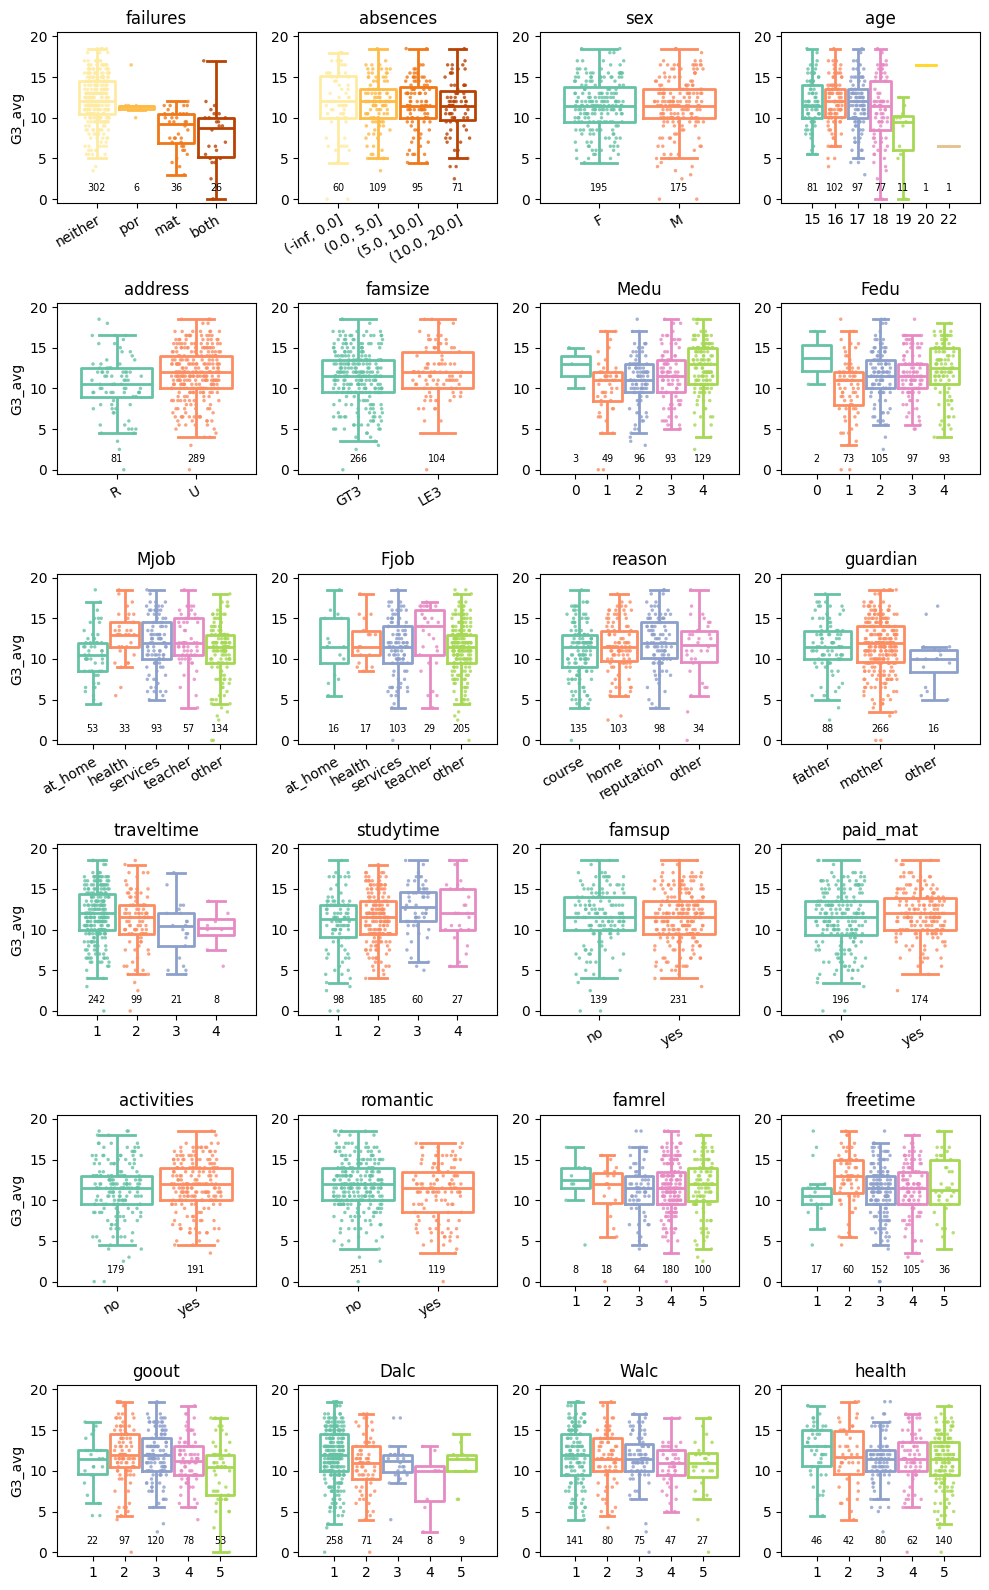

In [23]:
def lmbd_sort_index_otherlast(idx):
    ### to ensure that the 'other' group is the right-most boxplot
    return idx.map(lambda x: "zzz" if x == "other" else x)

columns_to_plot = ["failures", "absences"]+[col["name"] for (cid, col) in cols.iterrows()
                   if col["freq"] < 0.8 # and col["nb_represent"] < 5 and
                   and not col["name"].startswith("G") and not col["name"].startswith("index")
                        and "absence" not in col["name"] and "failure" not in col["name"]]

per_row = 4
f, axes = plt.subplots(6, per_row)
for ci, colname in enumerate(columns_to_plot):
    if colname == "failures":
        v_rep = colname
        vs = ["neither", "por", "mat", "both"]
        cs = spmandp_dtf[colname].value_counts().loc[vs].to_list()
        kwargs = {"hue_order": vs, "palette": "YlOrBr"}
    elif colname == "absences":
        v_rep = pandas.cut(spmandp_dtf[colname], [float("-Inf"),0,5,10,20])
        vs, cs = map(list, zip(*v_rep.value_counts().sort_index().items()))
        kwargs = {"hue_order": vs, "palette": "YlOrBr"}
    else:
        v_rep = colname
        vs, cs = map(list, zip(*spmandp_dtf[colname].value_counts()\
                               .sort_index(key=lmbd_sort_index_otherlast).items()))
        kwargs = {"hue_order": vs, "palette": "Set2"}

    seaborn.stripplot(spmandp_dtf, y="G3_avg", hue=v_rep, alpha=0.8, size=2.5,
                    ax=axes[ci//per_row, ci%per_row], dodge=True, jitter=.25,# width=1, gap=0.1,
                    legend=False, **kwargs)
    seaborn.boxplot(spmandp_dtf, y="G3_avg", hue=v_rep, fill=False, linewidth=2, showfliers=False,
                    ax=axes[ci//per_row, ci%per_row], dodge=True, width=0.8, gap=0.1,
                    legend=False, **kwargs)

    tick_pos = .8*((1+2*numpy.arange(len(vs)))/(2*len(vs))-0.5)
    if all([type(v) is int for v in vs]):
        axes[ci//per_row, ci%per_row].set_xticks(tick_pos, vs)
    else:
        axes[ci//per_row, ci%per_row].set_xticks(tick_pos, vs, rotation=30, ha="right", rotation_mode="anchor")
    for i, tpos in enumerate(tick_pos):
        axes[ci//per_row, ci%per_row].text(tpos, 1, cs[i], horizontalalignment="center", size="x-small")
    axes[ci//per_row, ci%per_row].set_ylim([-.5, 20.5])
    if ci%per_row > 0:
        axes[ci//per_row, ci%per_row].set_ylabel("")
    axes[ci//per_row, ci%per_row].set_title(colname)
f.set_figheight(16)
f.tight_layout()

Again, as expected from previous observations, more failures are associated with lower grades, whereas there is no such strong association between absences and grades.

There are about twenty more female students than male students (195 with **sex** value **F** vs. 175 with **sex** value **M**). Both groups have fairly similar grade distributions.

A large majority of students have urban addresses (289 with **address** value **U**). The median grade is lower for the minority of students with a rural address (81 with **address** value **R**).

We give the clarification of all attributes values, for further interpretation of the above figures.

- **school**: student's school
	- **GP**: *Gabriel Pereira*
	- **MS**: *Mousinho da Silveira*
- **sex**: student's sex
	- **F**emale
	- **M**ale
- **age**: student's age, from 15 to 22
- **address**: student's home address type
	- **U**rban
	- **R**ural
- **famsize**: family size
	- **LE3**: less or equal to 3
	- **GT3**: greater than 3
- **Pstatus**: parent's cohabitation status
	- **T**: living together
	- **A**: apart
- **Medu/Fedu**: mother's/father's education
	- **0**: none
	- **1**: primary education (4th grade)
	- **2**: 5th to 9th grade
	- **3**: secondary education
	- **4**: higher education
- **Mjob/Fjob**: mother's/father's job
	- **teacher**
	- **health**care related
	- civil **services** (e.g. administrative or police)
	- **at home**
	- **other**
- **reason**: reason to choose this school
	- close to **home**
	- school **reputation**
	- **course** preference
	- **other**
- **guardian**: student's guardian,
	- **mother**
	- **father**
	- **other**
- **traveltime**: home to school travel time
	- **1**: <15 min.
	- **2**: 15 to 30 min.
	- **3**: 30 min. to 1 hour
	- **4**: >1 hour
- **studytime**: weekly study time
	- **1**: <2 hours
	- **2**: 2 to 5 hours
	- **3**: 5 to 10 hours
	- **4**: >10 hours
- **failures**: number of past class failures, n if 1<=n<3, else 4
- **schoolsup**: extra educational support, yes/no
- **famsup**: family educational support, yes/no
- **paid**: extra paid classes within the course subject (Math or Portuguese), yes/no
- **activities**: extra-curricular activities, yes/no
- **nursery**: attended nursery school, yes/no
- **higher**: wants to take higher education, yes/no
- **internet**: Internet access at home, yes/no
- **romantic**: with a romantic relationship, yes/no
- **famrel**: quality of family relationships, from very bad (1) to excellent (5)
- **freetime**: free time after school, from very low (1) to very high (5)
- **goout**: going out with friends, from very low (1) to very high (5)
- **Dalc**: workday alcohol consumption, from very low (1) to very high (5)
- **Walc**: weekend alcohol consumption, from very low (1) to very high (5)
- **health**: current health status, from very bad (1) to very good (5)
- **absences**: number of school absences
- **G1**: first period grade, from 0 to 20
- **G2**: second period grade, from 0 to 20
- **G3**: final grade, from 0 to 20, output target